In [ ]:
"""
## Задание 2. Задача регрессии

Для набора данных "diamonds" из пакета seaborn:
1. Загрузите данные. Изучите набор данных, есть хорошая зависимость между числом карат бриллианта и его тремя x, y, z размерами.
2. Создайте новый поднабор данных df1 = df[['x', 'y', 'z', 'carat']] и очистите его от выбросов на основе ящика с усами.
3. Полученный набор данных разделите на тренировочную и тестовую выборку, обучите kNN регрессор и оцените точность модели. 
    Используйте все известные Вам метрики оценки качества решения задачи регрессии (3 балла).
"""

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
#1
"""
Чем больше карат его вес, тем больше физические размеры (больше координат x, y, z) бриллианта.
carat (карат) cut (огранка) color (цвет) clarity (чистота) depth (глубина) table (площадка) price (цена)
"""
df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


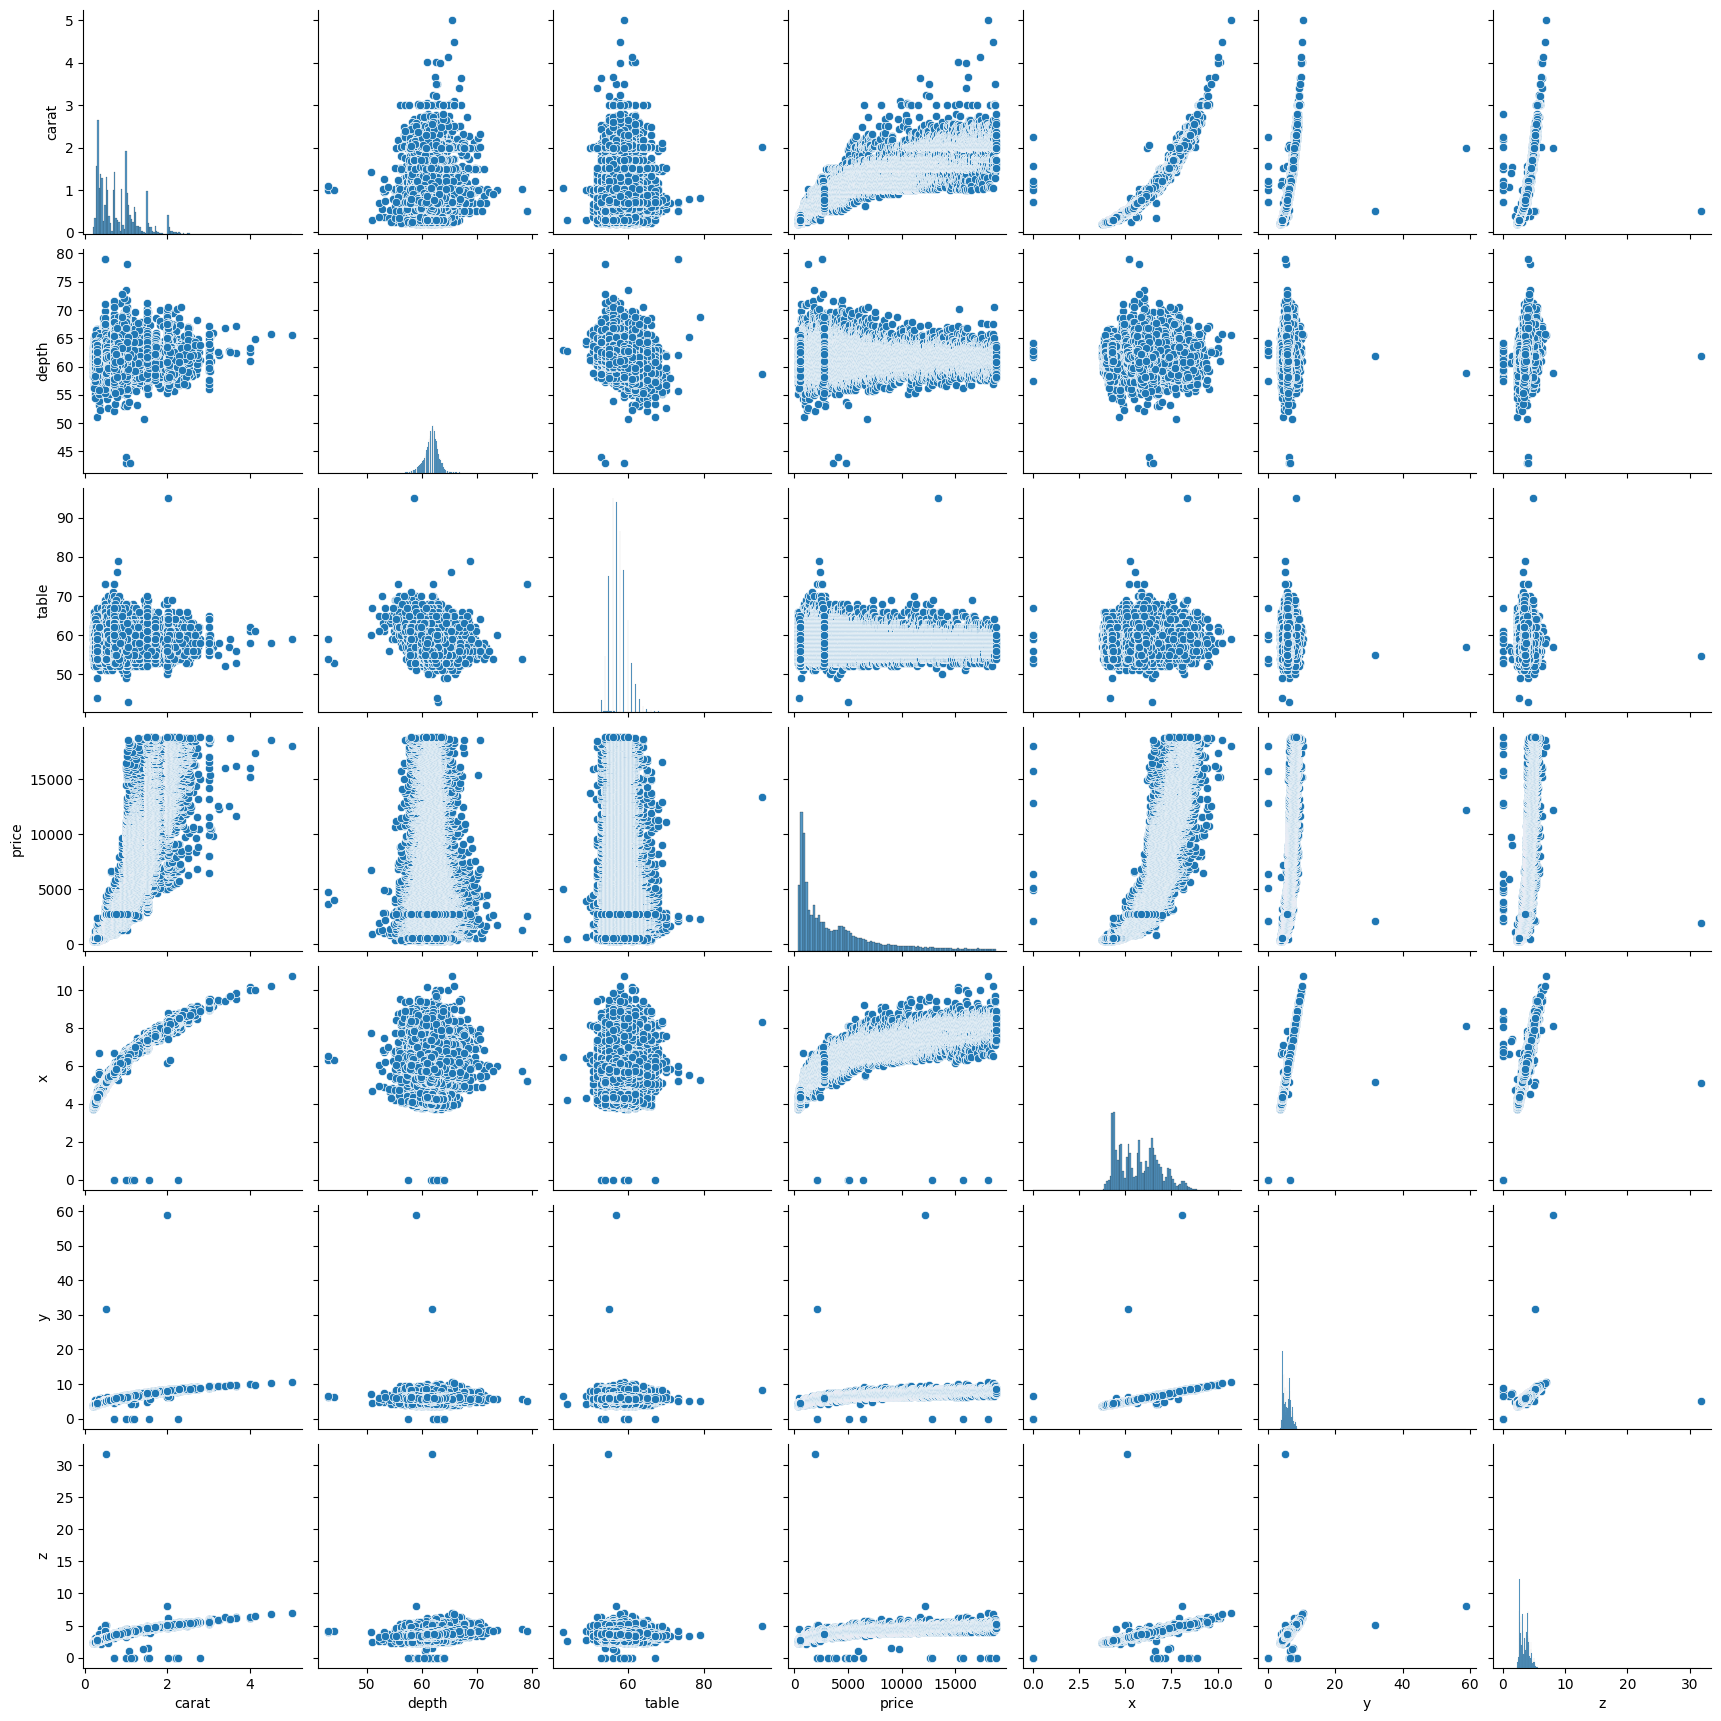

In [ ]:
"""
Видна высокая корреляция carat с x, y, z.
"""
sns.pairplot(df) # при желании можно посмотреть на pairplot, видна зависимость между carat и x,y,z

In [ ]:
#Видна высокая корреляция carat с x, y, z.
#Корреляция - это мера того, насколько две величины изменяются вместе.
df.corr(numeric_only=True).style.background_gradient(cmap='coolwarm')

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


In [5]:
#2
df1 = df[['x', 'y', 'z', 'carat']]
df1.shape

(53940, 4)

In [14]:
#выводит основные статистические показатели для числовых столбцов
"""
Выборсы можно заметить при размерах бриллиант по Y и Z
Т.е. сравнивая max_y = 58.90 с 50% - то это разница в 10 раз (примерно)
max_z = 31.80 с 50% - это разница в 9 раз (примерно)
Также странно, что min_x, min_y, min_z - нулевые значения, т.к. размеры бриллиант не могут быть меньше
Также странно, что при 75% размер бриллианта по Y равна 6.54, а максимальное это 58.90 (т.е. при 100%) 
    - это мб, но тогда это очень большой кусок бриллианта
"""
df1.describe().T # видно наличие выбросов. ГДЕ ВИДНО?

,count,mean,std,min,25%,50%,75%,max
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01


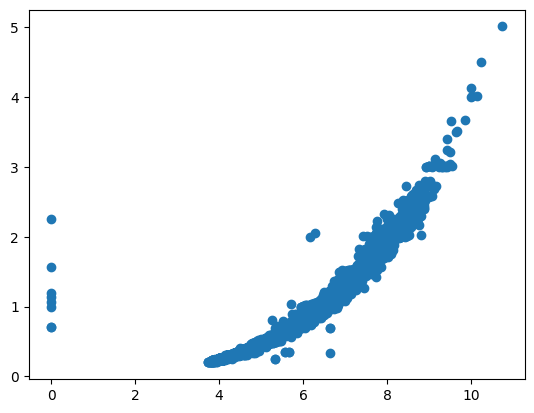

In [ ]:
"""
На оси Х - это значения столбца х - длина 
На оси У - это значения столбца carat - вес

Здесь можно заметить, что при X = 0 есть веса бриллианта [0.7; 2.3] - странно
Также при x > 11 carat/вес резко увеличивается в весе  (почти 5) - это тоже странно, но мб - надо делать проверку
    Либо очищать от выбросов!
"""
plt.scatter(df1['x'], df1['carat'])  # Здесь тоже видно выбросы

In [16]:
#Очистим df1 от выбросов следующим образом. Все, что выходит за 1.5 межквартильного интервала - считаем выбросом и удаляем.
Q1 = df1.quantile(0.25)
Q3 = df1.quantile(0.75)
IQR = Q3 - Q1

outliers = (df1 < (Q1 - 1.5 * IQR)) | (df1 > (Q3 + 1.5 * IQR))

df2 = df1[~outliers.any(axis=1)]
df2.shape

(52033, 4)

In [17]:
df2.describe().T # Видно, что стало меньше выбросов

,count,mean,std,min,25%,50%,75%,max
x,52033.0,5.639868,1.026844,3.73,4.69,5.65,6.48,8.42
y,52033.0,5.642594,1.020042,3.68,4.70,5.66,6.47,8.35
z,52033.0,3.483037,0.634845,1.41,2.89,3.49,4.01,5.37
carat,52033.0,0.748625,0.402067,0.20,0.39,0.70,1.02,2.00


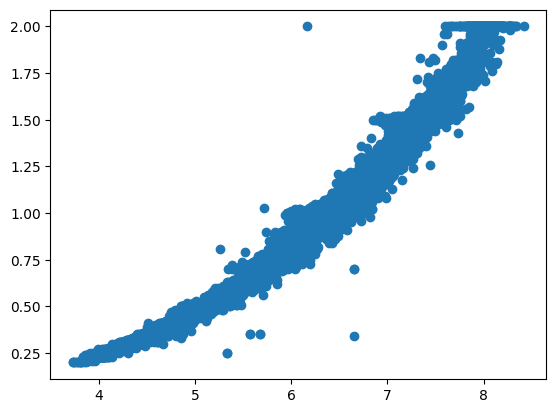

In [ ]:
plt.scatter(df2['x'], df2['carat'])  

In [20]:
#3
X_train, X_test, y_train, y_test = train_test_split(df2[['x','y','z']], df2['carat'], test_size = 0.2, random_state=12)